In [1]:
import numpy as np
import matplotlib.pyplot as plt
from girsanov_uq.utils.utils import  compute_probability_pdf, compute_probability_violin
import warnings
warnings.filterwarnings("ignore")


In [2]:
data_fit = np.load('./data_1D/reweighting_aggregate_fit_40_500.npz')
probs = np.concatenate([data_fit['ams_probabilities']], axis=0)
scores = np.concatenate([data_fit['all_scores']], axis=0)
fims = np.concatenate([data_fit['all_fims']], axis=0)

data_target = np.load('./data_1D/reweighting_aggregate_target_40_500.npz')
sigma = np.load('./pops_data/misspecification_sigma.npy')
probs_ref = data_target['ams_probabilities']

samples = np.load('./pops_data/posterior_samples.npy')

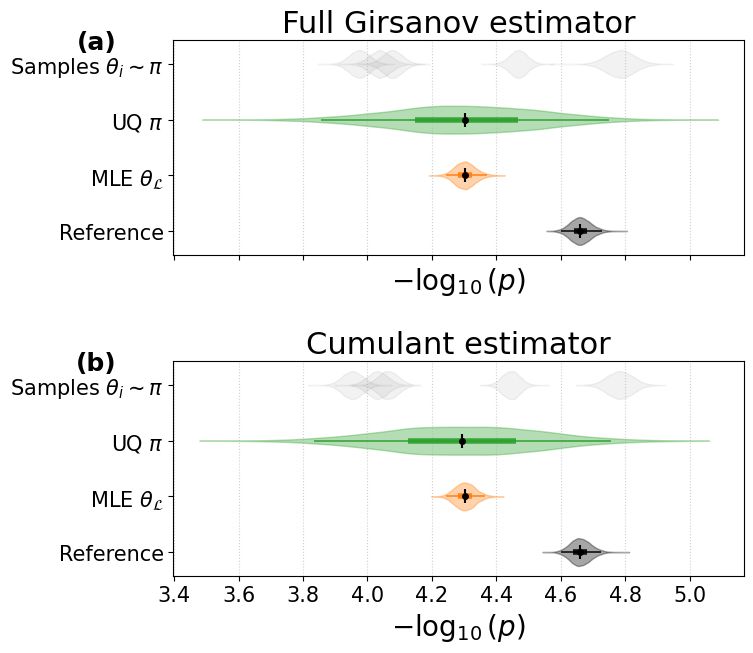

In [ ]:
import matplotlib.pyplot as plt
methods = ['full', 'loglinear']
fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
samples_id = np.array(range(5))
for i, method in enumerate(methods):
    compute_probability_violin(scores[:], probs[:], thetas_sample=samples, fims=fims, ref_probs=probs_ref, 
                            method=method, 
                            prior_dist='lognormal',
                            variance='estimator',
        ax=axs[i],
        use_Ahat=True,
        n_samples=10000,
        rng=42 + i,theta_plot_indices=samples_id)
axs[0].set_title('Full Girsanov estimator')
axs[1].set_title('Cumulant estimator')
axs[0].text(-0.1, 1.05, '(a)', transform=axs[0].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[1].text(-0.1, 1.05, '(b)', transform=axs[1].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')

# axs[1].get_legend().remove()
fig.tight_layout()
fig.savefig('toy_model_combined.png', dpi=300)